In [4]:
import pandas as pd
import numpy as np 
from pandasql import sqldf

In [6]:
df = pd.read_excel("C:/Users/umed/Downloads/GL90_тренировочные_данные.xlsx", sheet_name='Loans_Master')
df.head()

,loan_id,vintage_quarter,channel,origination_month,original_amount
0,L9001,2024_2,Offline,2024-07,23000
1,L9002,2024_2,Offline,2024-07,18000
2,L9003,2024_2,Offline,2024-06,19000
3,L9004,2024_2,Offline,2024-05,25000
4,L9005,2024_2,Offline,2024-06,25000


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2915 entries, 0 to 2914
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   loan_id            2915 non-null   str  
 1   vintage_quarter    2915 non-null   str  
 2   channel            2915 non-null   str  
 3   origination_month  2915 non-null   str  
 4   original_amount    2915 non-null   int64
dtypes: int64(1), str(4)
memory usage: 114.0 KB


In [11]:
df_znam = sqldf("""SELECT vintage_quarter, SUM(original_amount) FROM df WHERE channel = 'Offline' GROUP BY vintage_quarter ORDER BY vintage_quarter ASC""")
df_znam

,vintage_quarter,SUM(original_amount)
0,2024_2,3752000
1,2024_3,3087000
2,2024_4,2343000
3,2025_1,3525000
4,2025_2,2977000
5,2025_3,2571000
6,2025_4,3236000
7,2026_1,3719000


In [19]:
df_2 = pd.read_excel("C:/Users/umed/Downloads/GL90_тренировочные_данные.xlsx", sheet_name='Monthly_Performance')
df_2.head()

,loan_id,vintage_quarter,channel,snapshot_month,mob,balance,dpd_bucket
0,L9001,2024_2,Offline,2024-05,0,23000,Current
1,L9001,2024_2,Offline,2024-06,1,21965,Current
2,L9001,2024_2,Offline,2024-07,2,20930,Current
3,L9001,2024_2,Offline,2024-08,3,19895,Current
4,L9001,2024_2,Offline,2024-09,4,18860,Current


In [20]:
df_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 40997 entries, 0 to 40996
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   loan_id          40997 non-null  str  
 1   vintage_quarter  40997 non-null  str  
 2   channel          40997 non-null  str  
 3   snapshot_month   40997 non-null  str  
 4   mob              40997 non-null  int64
 5   balance          40997 non-null  int64
 6   dpd_bucket       40997 non-null  str  
dtypes: int64(2), str(5)
memory usage: 2.2 MB


In [21]:
df_issued = sqldf("""
    SELECT 
        loan_id,
        vintage_quarter,
        channel,
        balance AS original_amount
    FROM df_2
    WHERE mob = 0
""")
df_issued

,loan_id,vintage_quarter,channel,original_amount
0,L9001,2024_2,Offline,23000
1,L9002,2024_2,Offline,18000
2,L9003,2024_2,Offline,19000
3,L9004,2024_2,Offline,25000
4,L9005,2024_2,Offline,25000
...,...,...,...,...
2910,L11911,2026_1,Online,20000
2911,L11912,2026_1,Online,25000
2912,L11913,2026_1,Online,8000
2913,L11914,2026_1,Online,7000


In [24]:
df_flagged = sqldf("""
    SELECT 
        loan_id,
        vintage_quarter,
        channel,
        mob,
        CASE WHEN dpd_bucket IN ('30-59','60-89','90+','180+') THEN 1 ELSE 0 END AS ever30_flag,
        CASE WHEN dpd_bucket IN ('90+','180+') THEN 1 ELSE 0 END AS ever90_flag
    FROM df_2
""")
df_flagged

,loan_id,vintage_quarter,channel,mob,ever30_flag,ever90_flag
0,L9001,2024_2,Offline,0,0,0
1,L9001,2024_2,Offline,1,0,0
2,L9001,2024_2,Offline,2,0,0
3,L9001,2024_2,Offline,3,0,0
4,L9001,2024_2,Offline,4,0,0
...,...,...,...,...,...,...
40992,L11915,2026_1,Online,0,0,0
40993,L11915,2026_1,Online,1,0,0
40994,L11915,2026_1,Online,2,0,0
40995,L11915,2026_1,Online,3,0,0


In [26]:
df_first30 = sqldf("""
    SELECT loan_id, vintage_quarter, channel, MIN(mob) AS mob_first30
    FROM df_flagged
    WHERE ever30_flag = 1
    GROUP BY loan_id, vintage_quarter, channel
""")

df_first90 = sqldf("""
    SELECT loan_id, vintage_quarter, channel, MIN(mob) AS mob_first90
    FROM df_flagged
    WHERE ever90_flag = 1
    GROUP BY loan_id, vintage_quarter, channel
""")
df_first30

,loan_id,vintage_quarter,channel,mob_first30
0,L10016,2024_4,Online,18
1,L10019,2024_4,Online,13
2,L10023,2024_4,Online,11
3,L10027,2024_4,Online,7
4,L10032,2024_4,Online,12
...,...,...,...,...
248,L9982,2024_4,Online,13
249,L9983,2024_4,Online,5
250,L9989,2024_4,Online,14
251,L9990,2024_4,Online,5


In [27]:
df_first90

,loan_id,vintage_quarter,channel,mob_first90
0,L10016,2024_4,Online,18
1,L10019,2024_4,Online,13
2,L10023,2024_4,Online,11
3,L10027,2024_4,Online,7
4,L10032,2024_4,Online,12
...,...,...,...,...
248,L9982,2024_4,Online,13
249,L9983,2024_4,Online,5
250,L9989,2024_4,Online,14
251,L9990,2024_4,Online,5


In [28]:
df_ever30_event = sqldf("""
    SELECT 
        f.vintage_quarter,
        f.mob_first30 AS mob,
        SUM(i.original_amount) AS ever30_amount
    FROM df_first30 f
    JOIN df_issued i ON f.loan_id = i.loan_id
    WHERE f.channel = 'Offline'
    GROUP BY f.vintage_quarter, f.mob_first30
    ORDER BY f.vintage_quarter, f.mob_first30
""")

df_ever90_event = sqldf("""
    SELECT 
        f.vintage_quarter,
        f.mob_first90 AS mob,
        SUM(i.original_amount) AS ever90_amount
    FROM df_first90 f
    JOIN df_issued i ON f.loan_id = i.loan_id
    WHERE f.channel = 'Offline'
    GROUP BY f.vintage_quarter, f.mob_first90
    ORDER BY f.vintage_quarter, f.mob_first90
""")
df_ever90_event

,vintage_quarter,mob,ever90_amount
0,2024_2,5,11000
1,2024_2,6,77000
2,2024_2,8,6000
3,2024_2,9,13000
4,2024_2,14,18000
5,2024_2,15,15000
6,2024_2,16,37000
7,2024_2,17,8000
8,2024_2,18,31000
9,2024_3,5,8000


In [41]:


def build_ever_numerator(df_event, amount_col):
    vintages = df_event['vintage_quarter'].unique()
    rows = []
    for v in vintages:
        sub = df_event[df_event['vintage_quarter'] == v].set_index('mob')[amount_col]
        # максимальный MOB, который реально есть в данных для этой когорты
        max_mob_v = int(sub.index.max())
        cum = 0
        for m in range(1, max_mob_v + 1):
            if m in sub.index:
                cum += sub.loc[m]
            rows.append({
                'vintage_quarter': v,
                'mob': m,
                amount_col: cum
            })
    return pd.DataFrame(rows)

df_num_ever30 = build_ever_numerator(df_ever30_event, 'ever30_amount')
df_num_ever90 = build_ever_numerator(df_ever90_event, 'ever90_amount')
df_num_ever90

,vintage_quarter,mob,ever90_amount
0,2024_2,1,0
1,2024_2,2,0
2,2024_2,3,0
3,2024_2,4,0
4,2024_2,5,11000
...,...,...,...
94,2025_4,3,0
95,2025_4,4,0
96,2025_4,5,10000
97,2025_4,6,10000


In [42]:
df_of = df_of.rename(columns={'SUM(original_amount)': 'issued_amount'})

In [43]:
df_vintage_30 = df_num_ever30.merge(
    df_of,
    on='vintage_quarter',
    how='left'
)

df_vintage_90 = df_num_ever90.merge(
    df_of,
    on='vintage_quarter',
    how='left'
)

In [44]:
print(df_vintage_30['issued_amount'].isna().sum())  # 0
print(df_vintage_90['issued_amount'].isna().sum())  # 0

0
0


In [45]:
df_vintage_30['ever30_rate'] = df_vintage_30['ever30_amount'] / df_vintage_30['issued_amount']
df_vintage_90['ever90_rate'] = df_vintage_90['ever90_amount'] / df_vintage_90['issued_amount']

In [46]:

df_vintage = df_vintage_30.merge(
    df_vintage_90[['vintage_quarter', 'mob', 'ever90_amount', 'ever90_rate']],
    on=['vintage_quarter', 'mob'],
    how='outer'
).fillna(0)

In [50]:
# 1. ever90 ≤ ever30 на каждом MOB
viol = df_vintage[df_vintage['ever90_rate'] > df_vintage['ever30_rate']]
print(f"Нарушений ever90 > ever30: {len(viol)}")  # 0

# 2. ever30_rate не убывает с ростом MOB внутри когорты
for v in df_vintage['vintage_quarter'].unique():
    sub = df_vintage[df_vintage['vintage_quarter'] == v].sort_values('mob')
    assert sub['ever30_rate'].is_monotonic_increasing, f"Нарушение в {v}"
print("✅ Накопительный рост — ок")

# 3. Доля ≤ 100%
print(df_vintage['ever30_rate'].max())  # ≤ 1.0
print(df_vintage['ever90_rate'].max())  # ≤ 1.0

Нарушений ever90 > ever30: 0
✅ Накопительный рост — ок
0.07121263016459523
0.07121263016459523


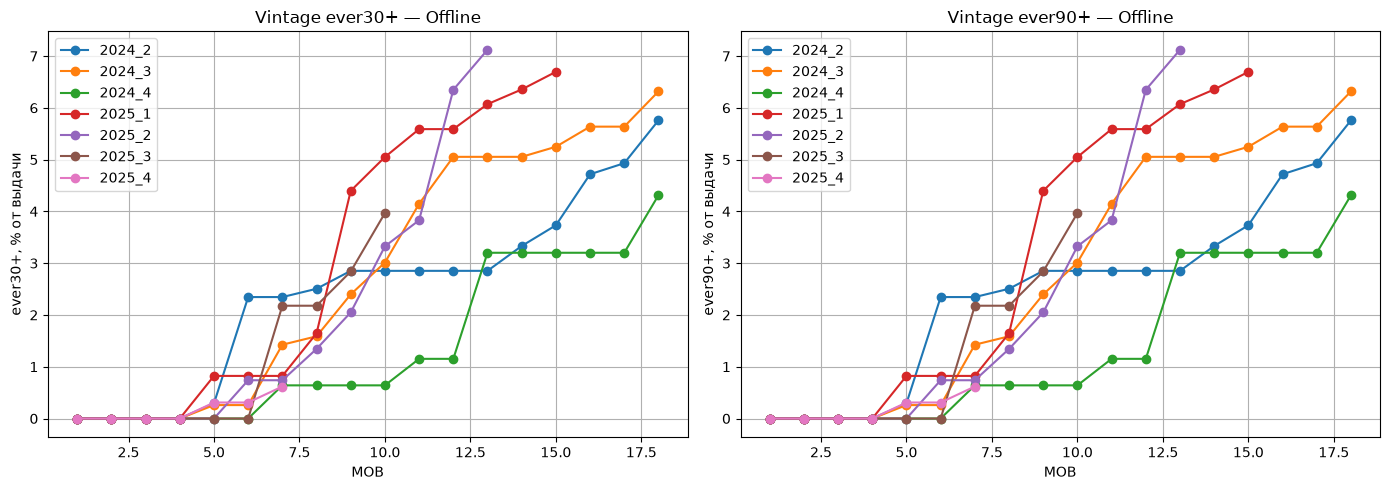

In [51]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for v in sorted(df_vintage['vintage_quarter'].unique()):
    sub = df_vintage[df_vintage['vintage_quarter'] == v].sort_values('mob')
    axes[0].plot(sub['mob'], sub['ever30_rate'] * 100, marker='o', label=v)
    axes[1].plot(sub['mob'], sub['ever90_rate'] * 100, marker='o', label=v)

axes[0].set_title('Vintage ever30+ — Offline')
axes[0].set_xlabel('MOB')
axes[0].set_ylabel('ever30+, % от выдачи')
axes[0].legend(); axes[0].grid(True)

axes[1].set_title('Vintage ever90+ — Offline')
axes[1].set_xlabel('MOB')
axes[1].set_ylabel('ever90+, % от выдачи')
axes[1].legend(); axes[1].grid(True)

plt.tight_layout()
plt.show()